In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


## 1.1: Grid (Syn Colliders x P_noise) and Samples (Noisy Logic Gates) 

In [ ]:
import pickle

subset = 'binary_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    # with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
    #     results_hc_inf = pickle.load(f)

    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)

    # with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
    #     results_ea_ies = pickle.load(f)
    
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        # "EA Informed": results_ea_ies,
        "EA Final Greedy": results_ea_fg,
        # "HC Informed": results_hc_inf,
        # "EA Uninformed": results_ea_ues,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)
# x_col="p_noise"
x_col="samples"
y_col="p_noise"
# y_col="samples"
# filter = ("samples", 10_000)
filter = ("p_syn", 0.5)
# filter = ("dag_family", "ba")
filter_col, filter_val = filter

# Binary Data 

## Global

In [ ]:
metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/global/benchmark_{metric}.png", dpi=600, bbox_inches='tight')

## Collider Metrics

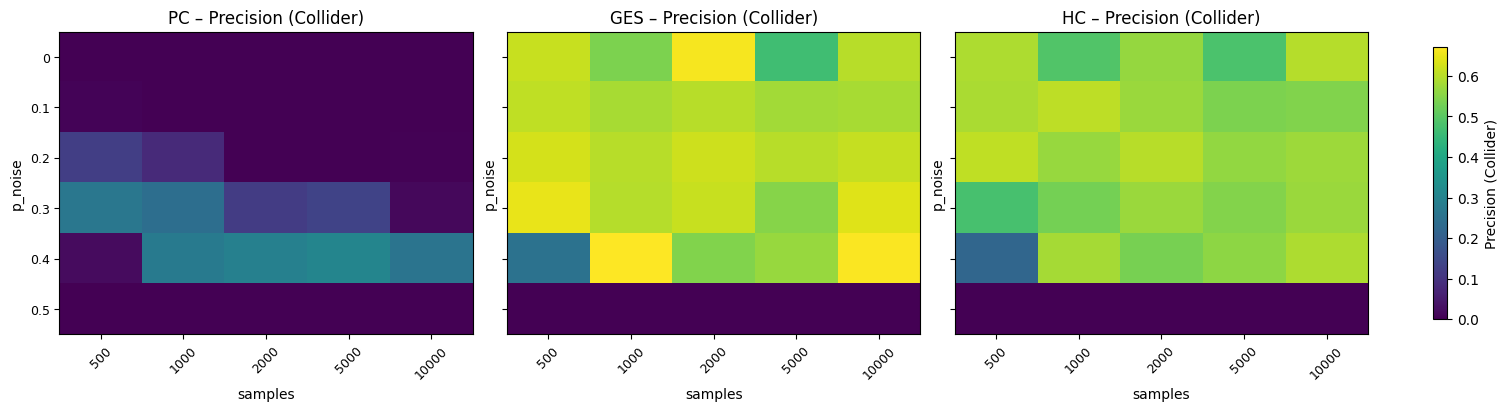

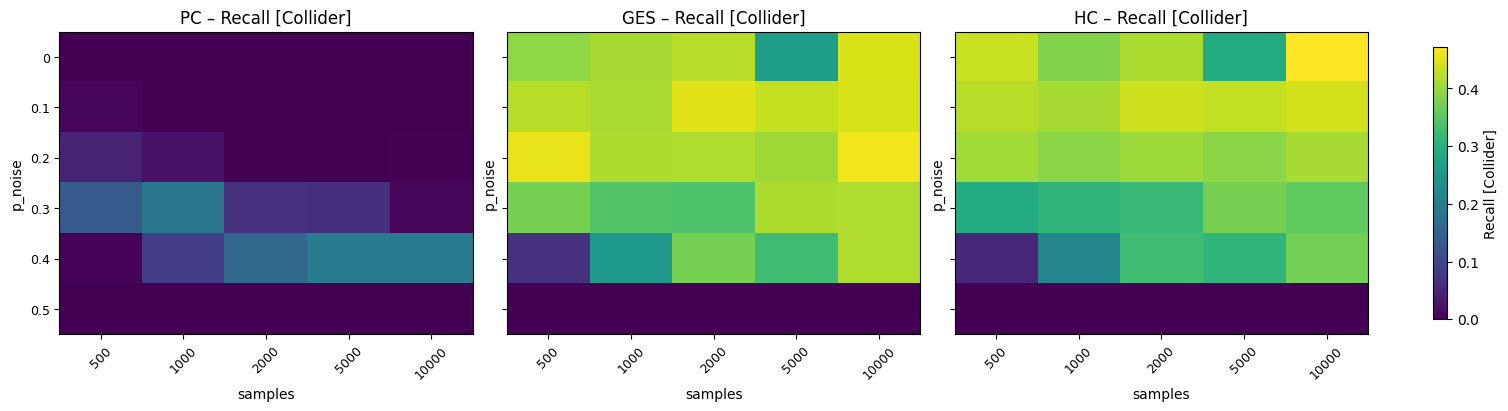

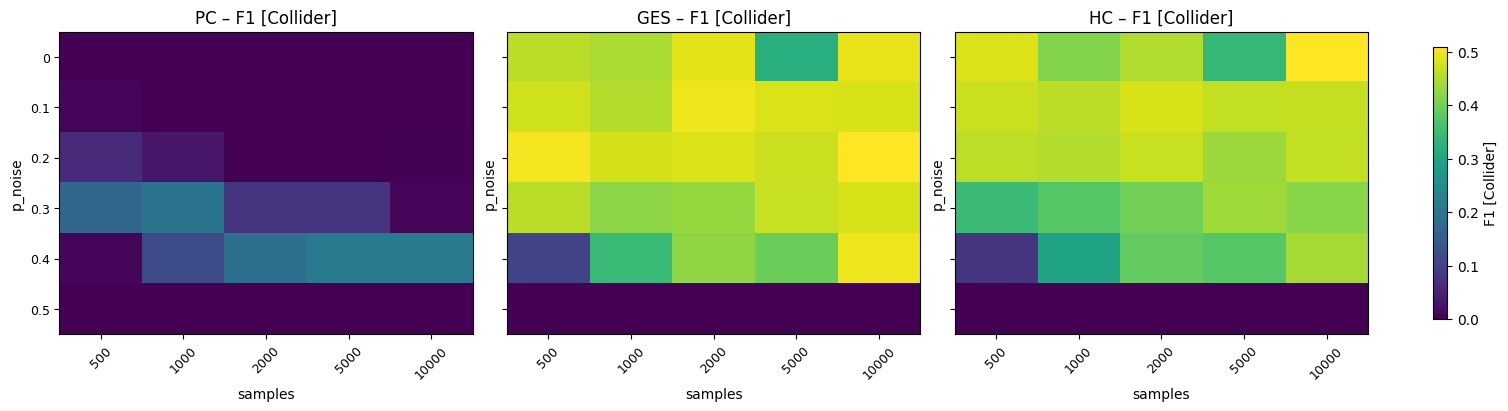

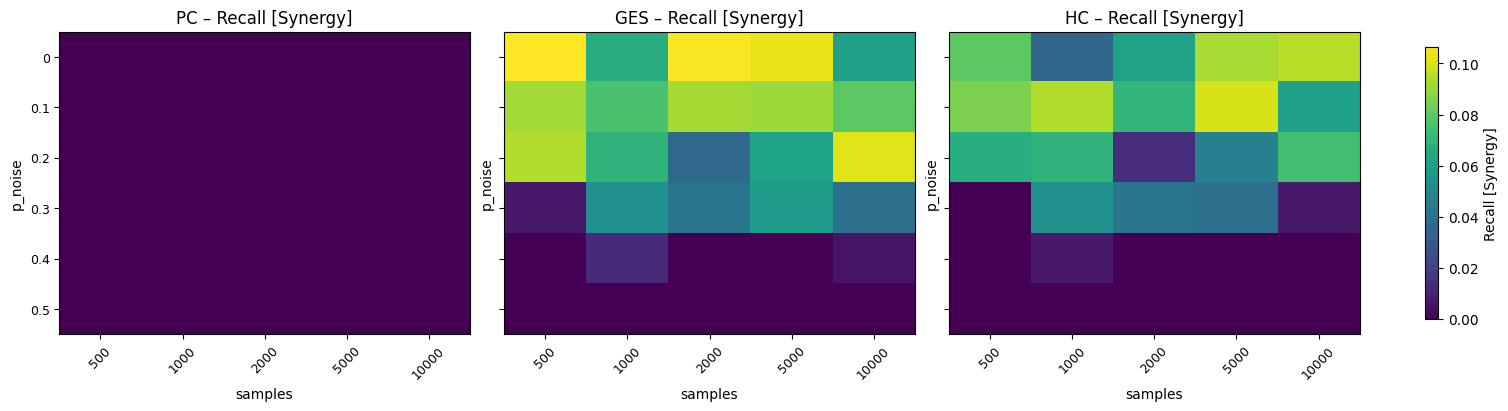

In [9]:
metrics = ["Precision (Collider)", "Recall [Collider]", "F1 [Collider]", "Recall [Synergy]"] 
for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/collider/benchmark_{metric}.png", dpi=600, bbox_inches='tight')


## JointPMFGrid

In [10]:
subset = 'jpmf_data'
load_results(subset)

### Global

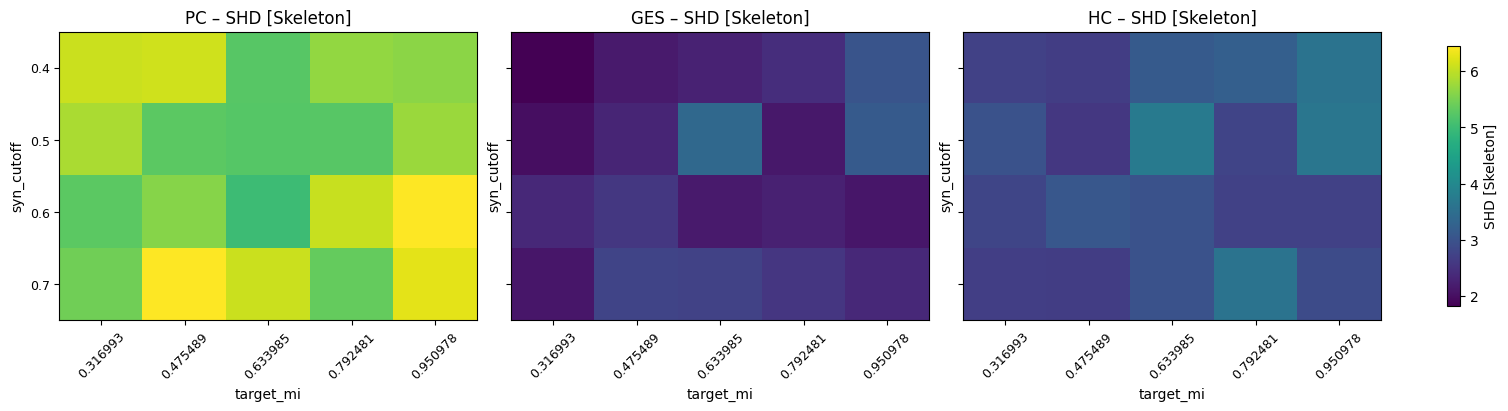

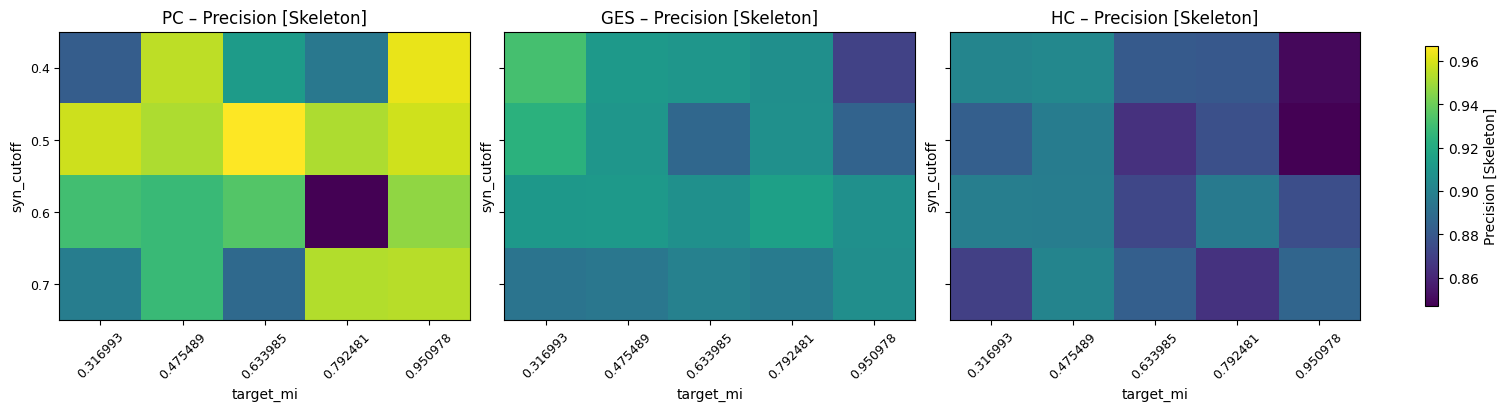

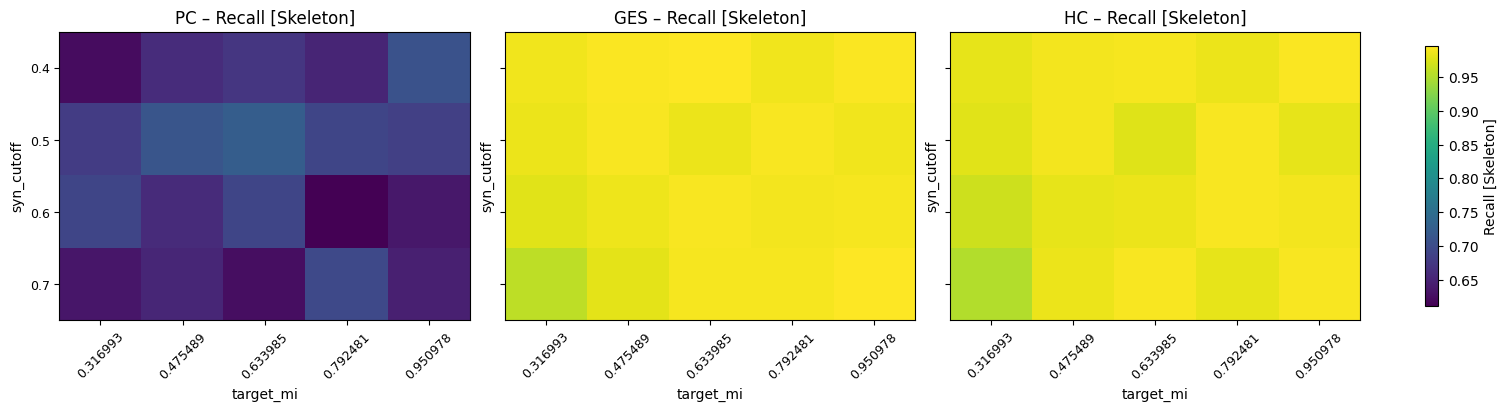

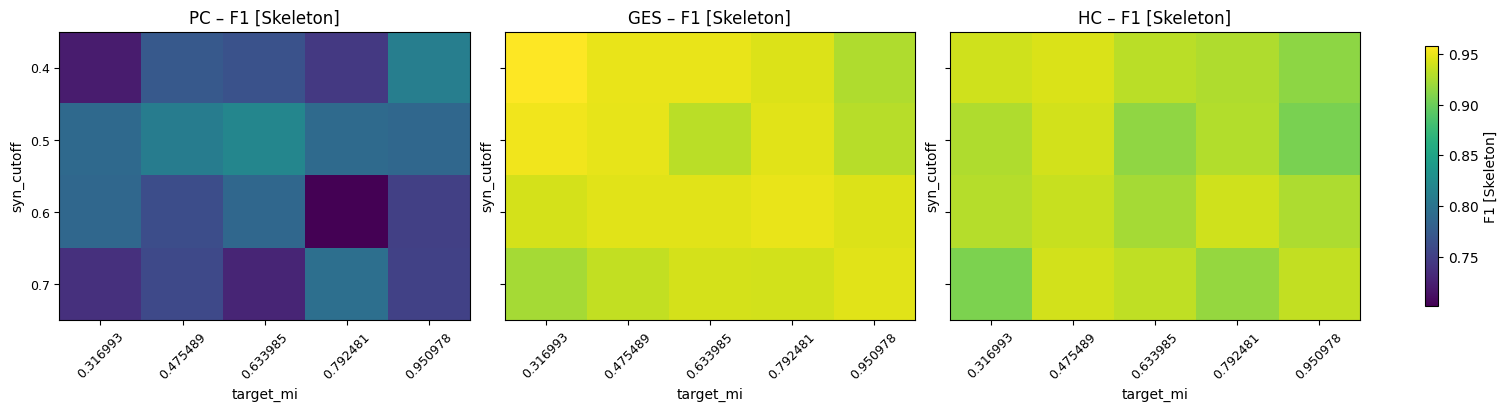

In [16]:
metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/global/benchmark_{metric}.png", dpi=600, bbox_inches='tight')

### Colliders 

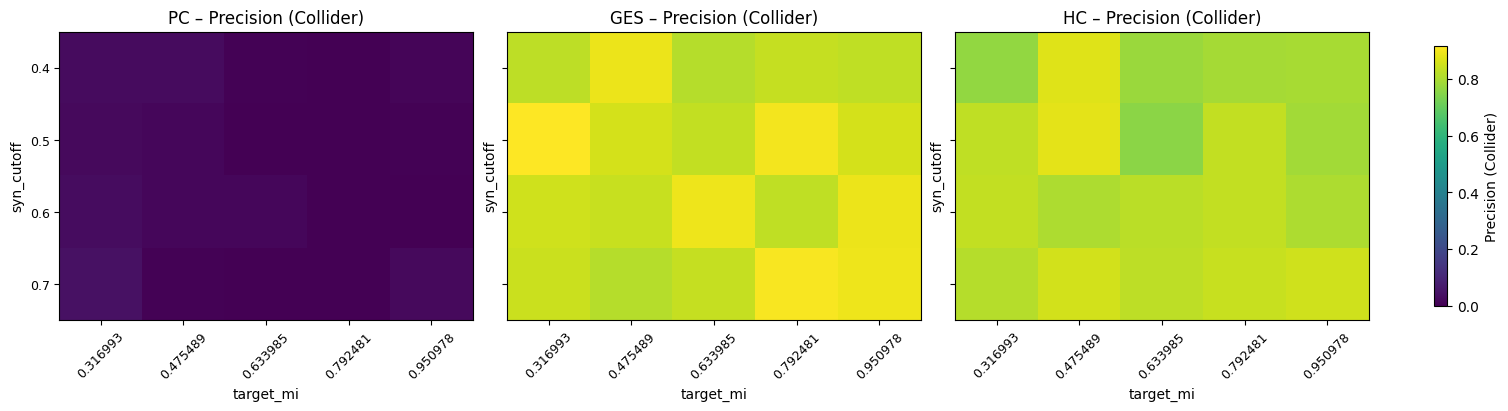

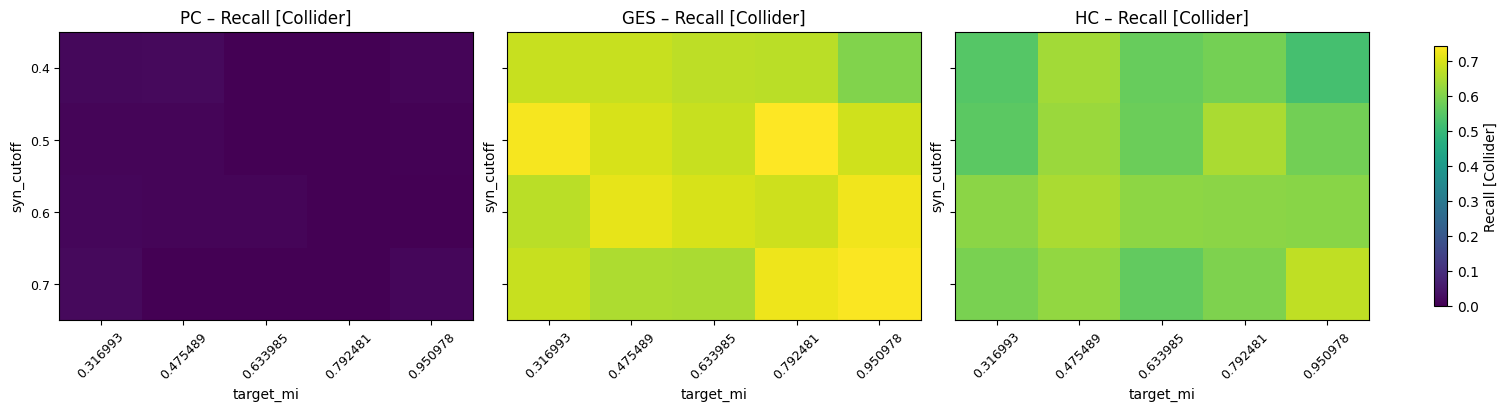

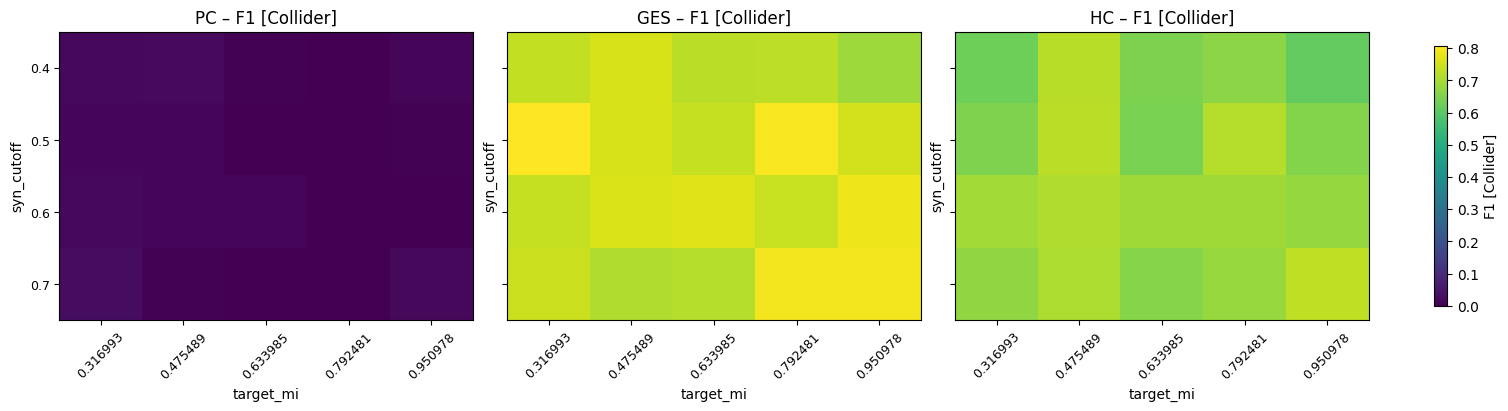

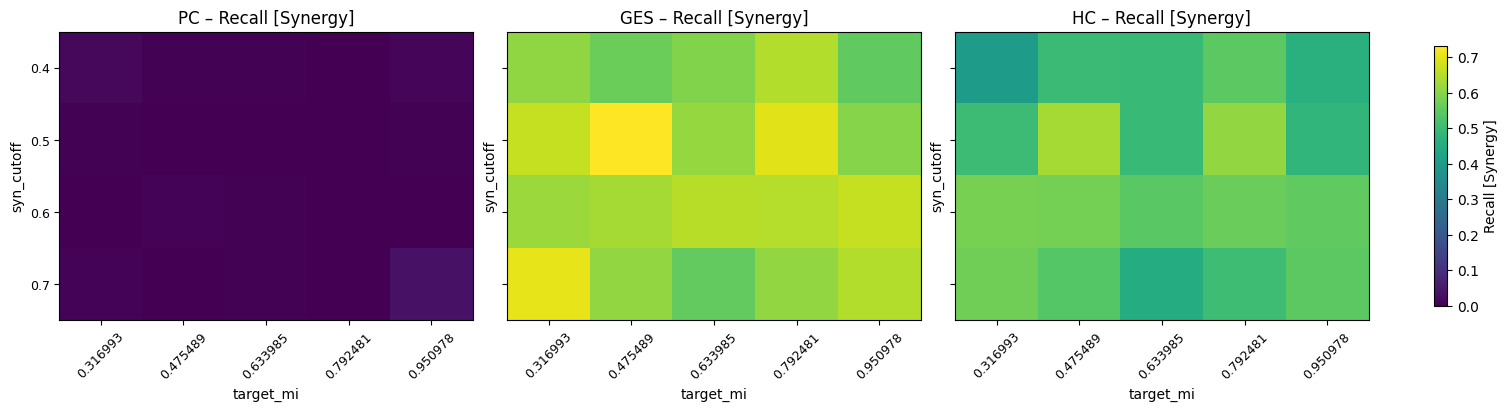

In [15]:
metrics = ["Precision (Collider)", "Recall [Collider]", "F1 [Collider]", "Recall [Synergy]"] 
for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/collider/benchmark_{metric}.png", dpi=600, bbox_inches='tight')


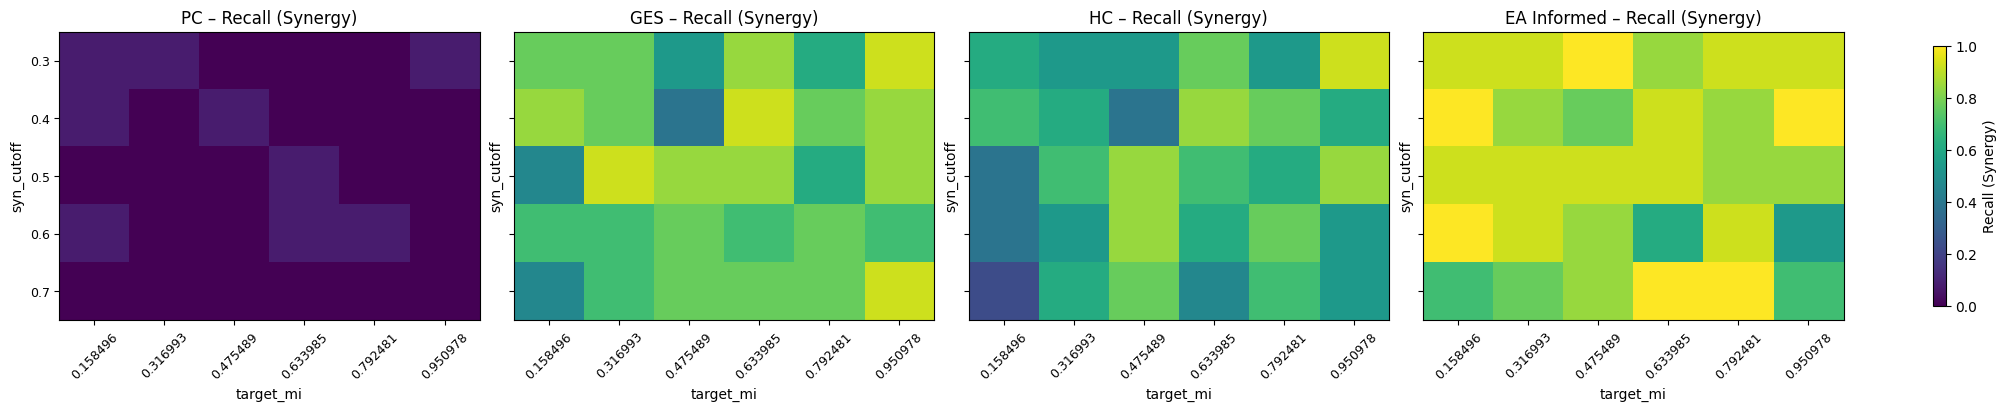

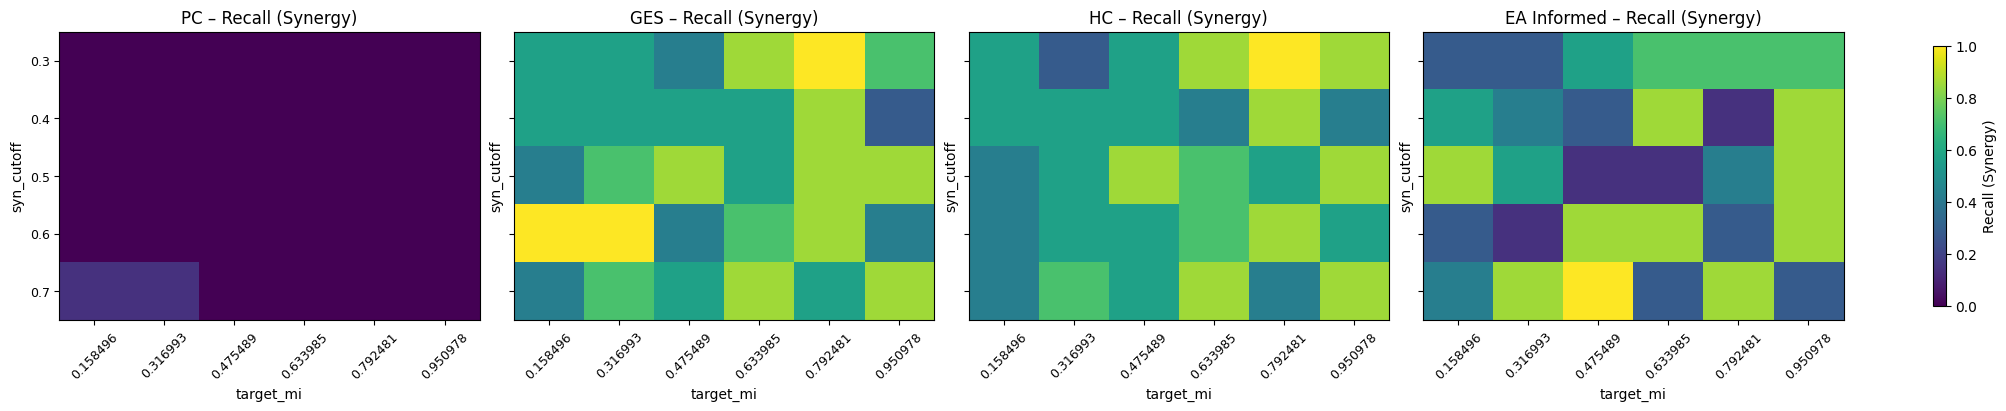

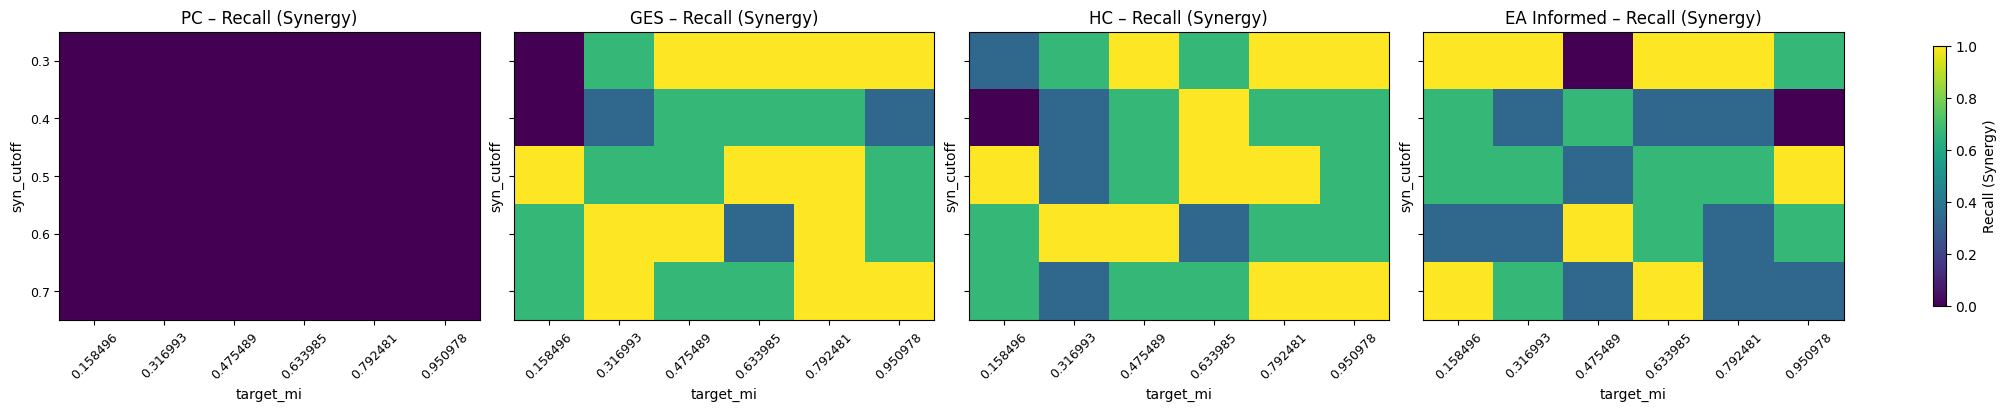

In [ ]:
# Pick the metric you want (change this string)
metric = "Recall (Synergy)"   # or "F1 (Collider)", "SHD", "Recall (Synergy)"

# for metric in ["SHD", "F1 (Collider)", "Recall (Synergy)", "Recall (Collider)"]:

for filter_val in [0.5, 0.7, 0.9]:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="median",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )


    plt.savefig(f"plots/RQ1_JPMFPairs{filter_val}_{metric}.png", dpi=800)


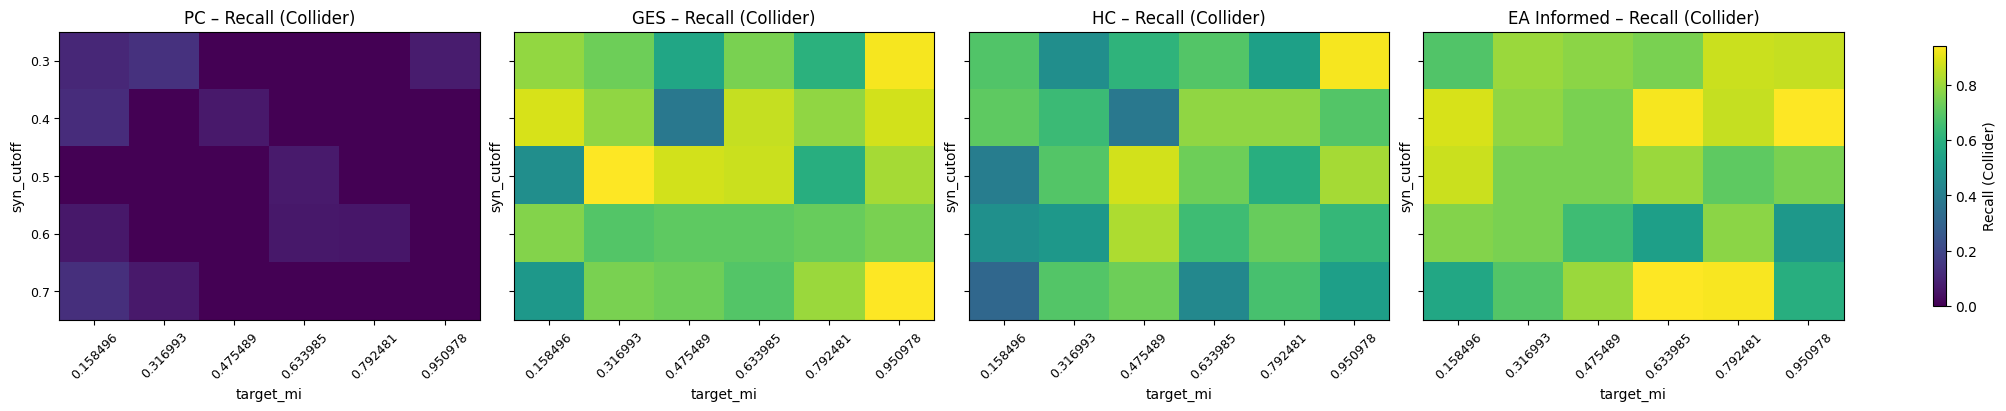

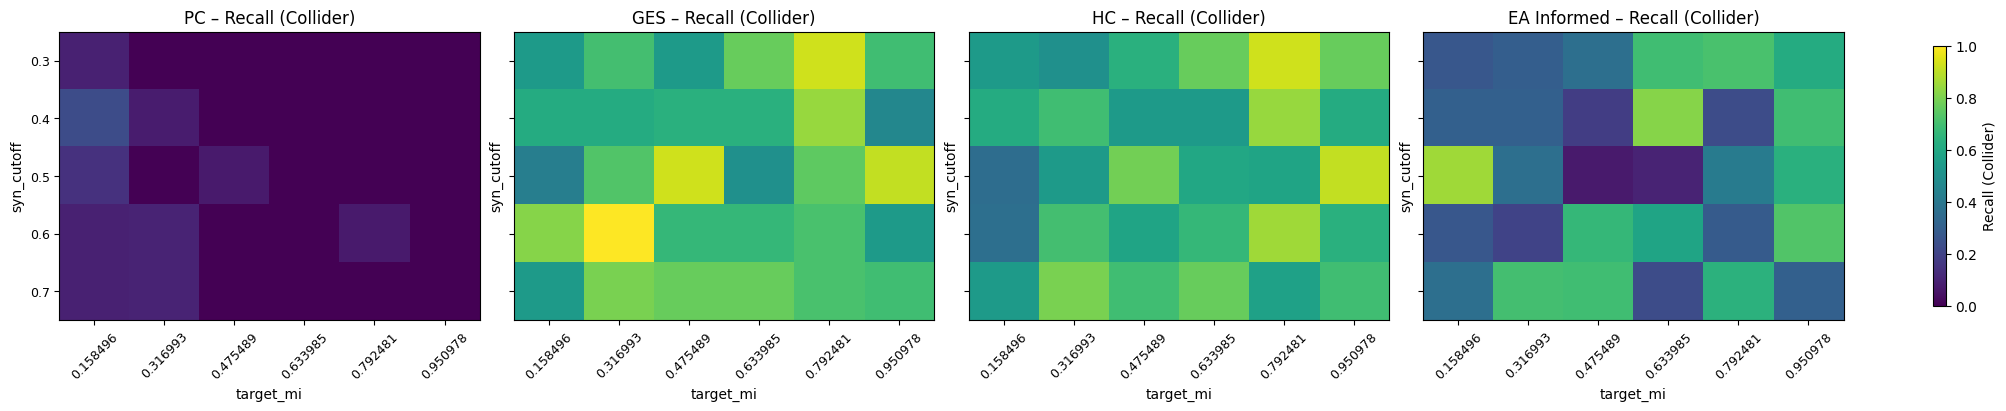

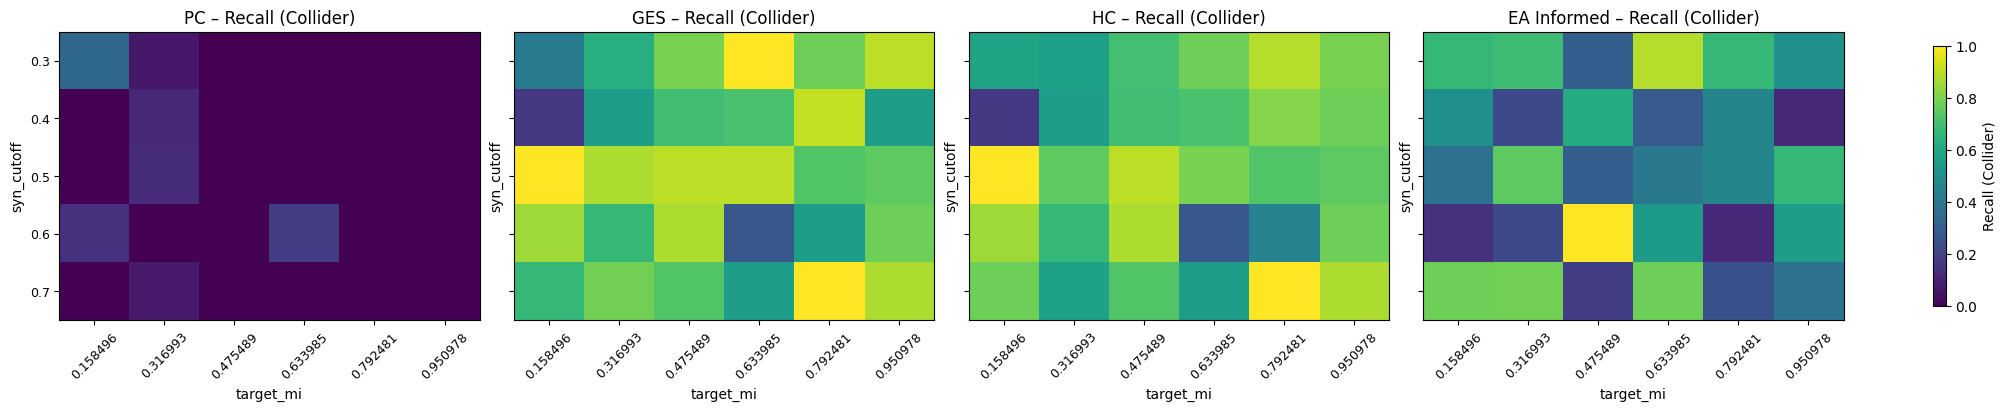

In [ ]:
# Pick the metric you want (change this string)
metric = "Recall (Collider)"   # or "F1 (Collider)", "SHD", "Recall (Synergy)"
# x_col="p_noise"
# y_col="n_xor"
# Close prior figures to avoid stacking / memory leaks
# plt.close("all")

# for metric in ["SHD", "F1 (Collider)", "Recall (Synergy)", "Recall (Collider)"]:
for filter_val in [0.5, 0.7, 0.9]:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        filter=(filter_col, filter_val),
        y_col=y_col,
        aggfunc="median",
    )


    plt.savefig(f"plots/RQ1_JPMFPairs{filter_val}_{metric}.png", dpi=800)


In [19]:
import pandas as pd

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

long_df = build_long_metrics(results_by_label)


### Metrics

In [ ]:
# ea_long = long_df[long_df["Algorithm"].str.contains("EA")]

In [ ]:
# subset_df = ea_long[
#     (ea_long["pair_probs"] == 0.5) & 
#     (ea_long["syn_cutoff"] == 0.7)
# ]

In [82]:
# min(subset_df["Recall (Synergy)"])

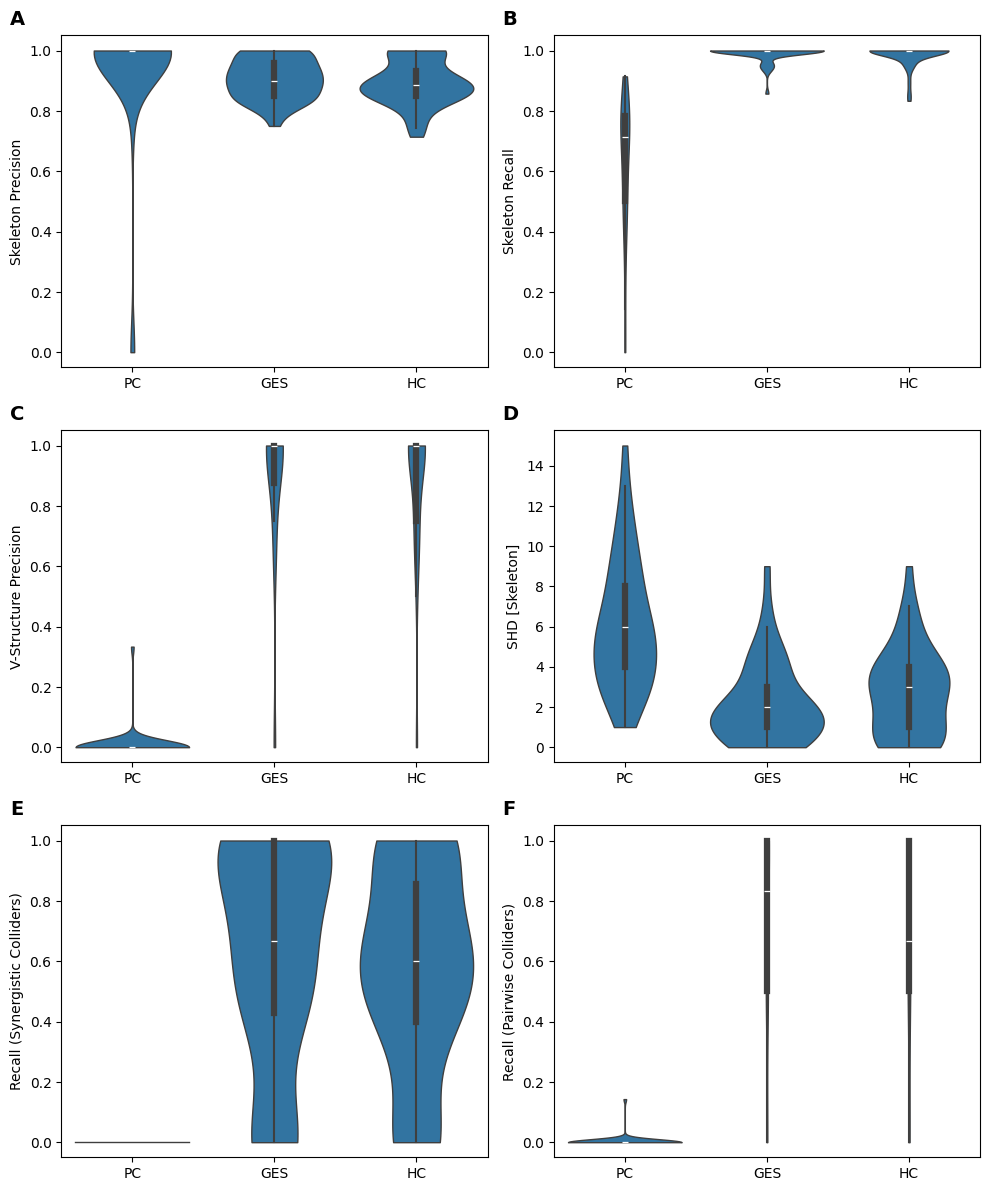

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


metrics = {
    "A": ("Precision [Skeleton]", "Skeleton Precision"),
    "B": ("Recall [Skeleton]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall [Synergy]", "Recall (Synergistic Colliders)"),
    "F": ("Recall [Pairwise]", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC"] #  , "EA Informed"] 

# Example slice (optional):
filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.7}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/jpmf_data//RQ1_Violin_{subset}_pairs{filter_dict['pair_probs']}_syn{filter_dict['syn_cutoff']}.png",
    dpi=800,
)


## 1.3: Tradeoffs EA+HC

In [13]:
import pickle

subset = 'binary_grid'
subset = 'jpmf_grid'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_hc_inf = pickle.load(f)

    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA-I": results_ea_ies,
        "EA-FG": results_ea_fg,
        # "HC Informed": results_hc_inf,
        # "EA Uninformed": results_ea_ues,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)

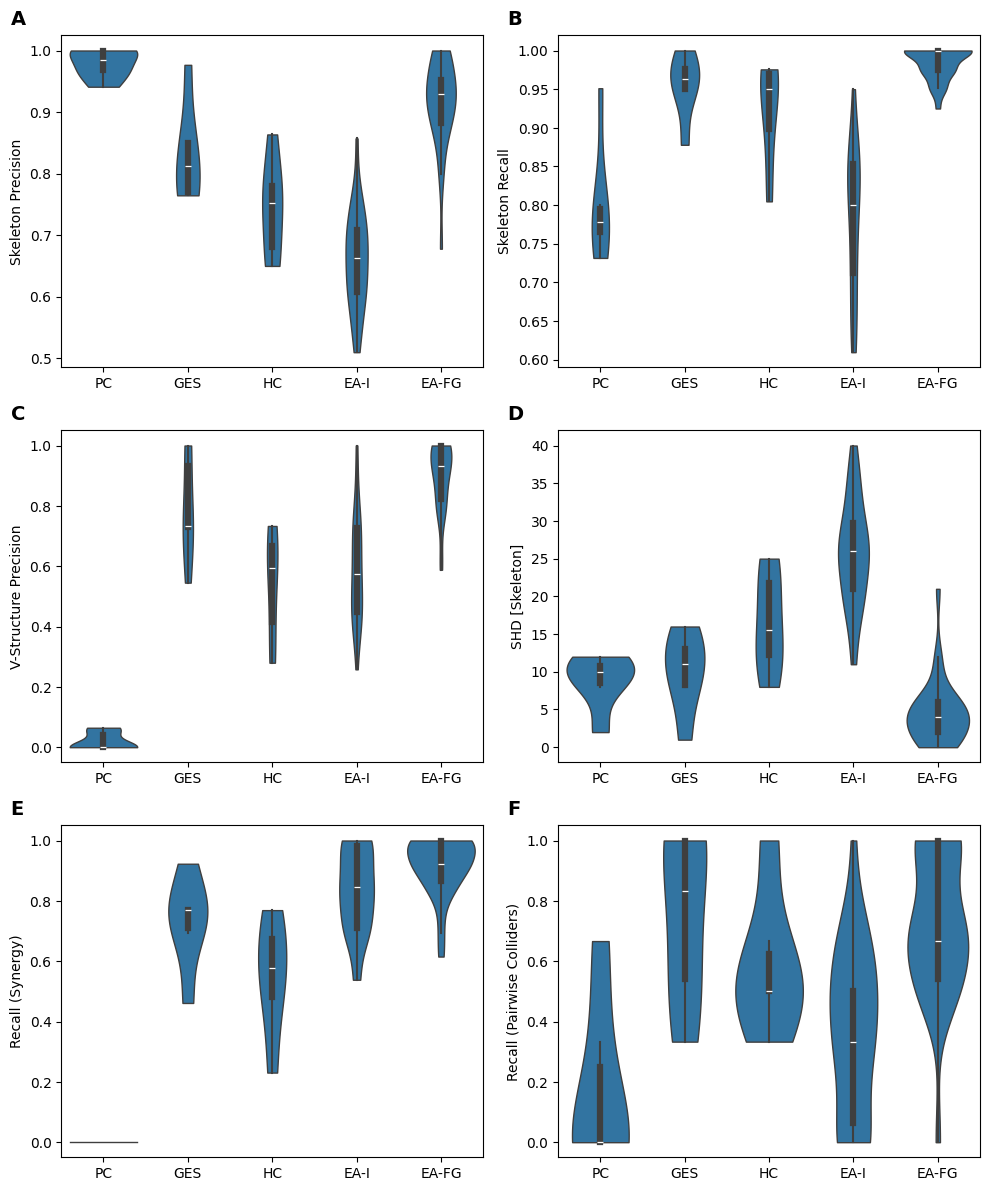

In [14]:
long_df = build_long_metrics(results_by_label)

metrics = {
    "A": ("Precision [Adjacency]", "Skeleton Precision"),
    "B": ("Recall [Adjacency]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall (Synergy)", "Recall (Synergy)"),
    "F": ("Recall (Pairwise)", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC", "EA-I", "EA-FG"]  # or whatever you want

# Example slice (optional):
filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.7}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/RQ2_Violin_{subset}_pairs{filter_dict['pair_probs']}_syn{filter_dict['syn_cutoff']}.png",
    dpi=800,
)


In [15]:
### Metrics and Algorithms
np.unique(long_df["Algorithm"])

array(['EA-FG', 'EA-I', 'GES', 'HC', 'PC'], dtype=object)

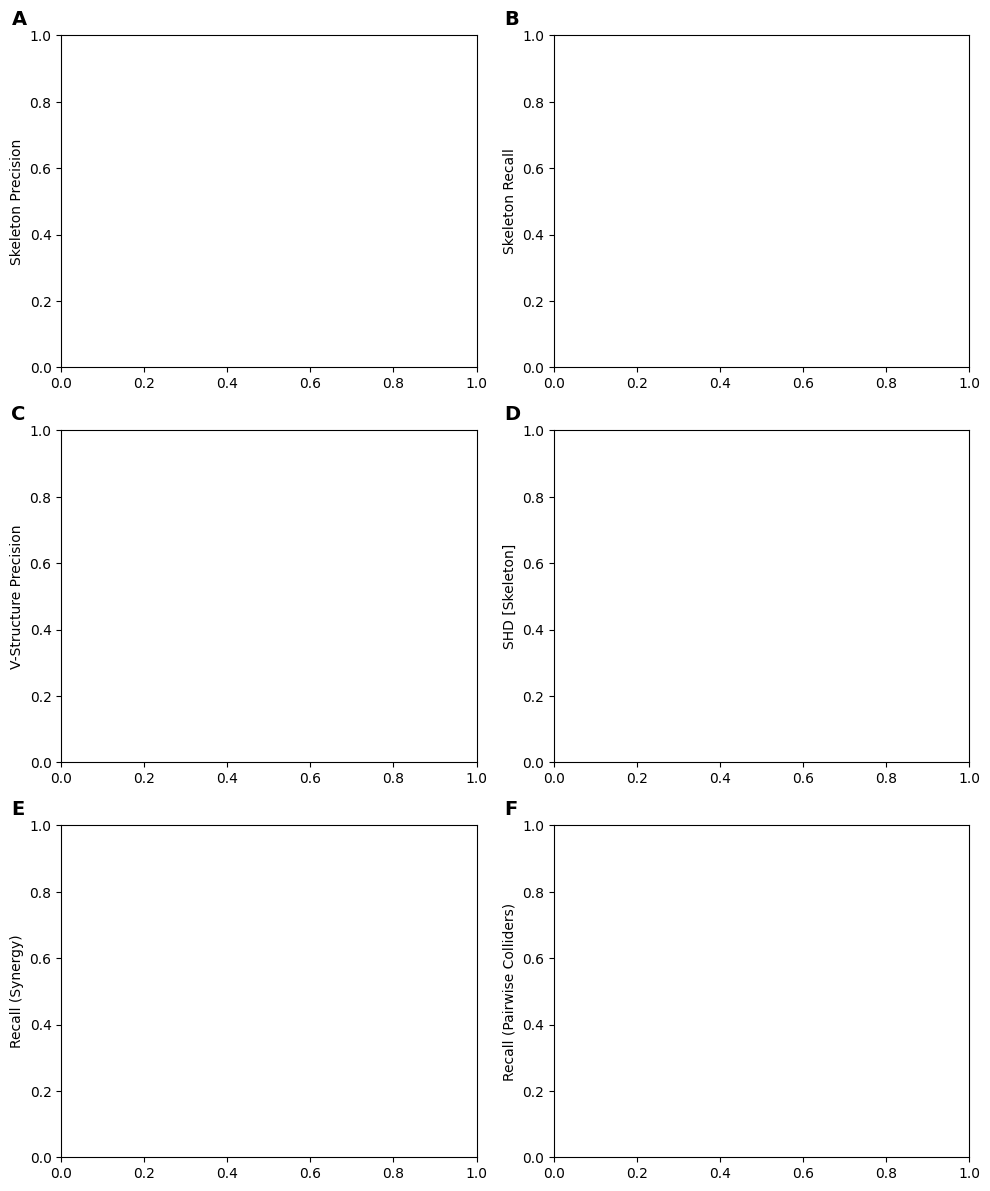

In [16]:

metrics = {
    "A": ("Precision [Adjacency]", "Skeleton Precision"),
    "B": ("Recall [Adjacency]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall (Synergy)", "Recall (Synergy)"),
    "F": ("Recall (Pairwise)", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC", "EA-I", "EA-FG"]  # or whatever you want

# Example slice (optional):
filter_dict = {"pair_probs": 0.3}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/RQ2_Violin_{subset}_pairs{filter_dict['pair_probs']}.png",
    dpi=800,
)
